# Experiment — Temporal Convolutional Network (discarded)

A dilated-causal TCN (`Chomp1d`, `TemporalBlock`, `TemporalAttentionPooling`, `TCNHybrid`) with an Optuna study, tested as an alternative to the recurrent encoder.

**Best validation weighted-F1: 0.9272** — competitive but never better than CNN-GRU, and substantially slower to train, so it was dropped.

---


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain: pirate_pain_train.csv, pirate_pain_train_labels.csv,
# pirate_pain_test.csv, sample_submission.csv  (see data/README.md)
import os

DATA_DIR = os.environ.get("PIRATE_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## Libraries Import


In [2]:
# @title
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, Dataset, DataLoader, WeightedRandomSampler
logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from sklearn.model_selection import StratifiedGroupKFold
import optuna
from optuna.trial import Trial
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold

PyTorch version: 2.8.0+cu126
Device: cuda


## Data Processing


In [3]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

In [4]:
X_train = pd.read_csv('../Dataset/pirate_pain_train.csv')
y_train = pd.read_csv('../Dataset/pirate_pain_train_labels.csv')
X_test = pd.read_csv('../Dataset/pirate_pain_test.csv')

# Remove rows with any missing values
X_train.dropna(axis=0, how='any', inplace=True)
y_train.dropna(axis=0, how='any', inplace=True)
X_test.dropna(axis=0, how='any', inplace=True)

# Check for and drop columns with only one unique value
cols_to_drop = []
for col in X_train.columns:
  if X_train[col].nunique() == 1:
    print(f"Column '{col}' has only one unique value")
    cols_to_drop.append(col)

X_train = X_train.drop(columns=cols_to_drop)

# Check unique values in 'n_legs', 'n_hands', and 'n_eyes'
print("Unique values in 'n_legs':", X_train['n_legs'].unique())
print("Unique values in 'n_hands':", X_train['n_hands'].unique())
print("Unique values in 'n_eyes':", X_train['n_eyes'].unique())

# Define a mapping for string representations of strings to integers
legs_mapping = {
    'two': 2,
    'one+peg_leg': 1
}

hands_mapping = {
    'two': 2,
    'one+hook_hand': 1
}

eyes_mapping = {
    'two': 2,
    'one+eye_patch': 1
}

# Convert 'n_legs', 'n_hands', and 'n_eyes' to integers using the mapping
X_train['n_legs'] = X_train['n_legs'].map(legs_mapping)
X_train['n_hands'] = X_train['n_hands'].map(hands_mapping)
X_train['n_eyes'] = X_train['n_eyes'].map(eyes_mapping)

X_test['n_legs'] = X_test['n_legs'].map(legs_mapping)
X_test['n_hands'] = X_test['n_hands'].map(hands_mapping)
X_test['n_eyes'] = X_test['n_eyes'].map(eyes_mapping)

# Define a mapping of status names to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

# Map status names to integers in the labels set
y_train['label'] = y_train['label'].map(label_mapping)

# Convert 'joint_*' columns to float32 data type to use less memory
for col in X_train.columns:
  if 'joint' in col:
    X_train[col] = X_train[col].astype(np.float32)

for col in X_test.columns:
  if 'joint' in col:
    X_test[col] = X_test[col].astype(np.float32)

# StratifiedGroup Split
df_subjects = (X_train[['sample_index']]
    .drop_duplicates()
    .merge(y_train, on='sample_index')
)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(
    df_subjects,
    df_subjects['label'],
    groups=df_subjects['sample_index']
))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]

# Define the columns to be normalised
num_joints = 29
joint_cols = [f'joint_{i:02d}' for i in range(num_joints+1)]

# Calculate the minimum and maximum values from the training data only
mins = df_train[joint_cols].min()
maxs = df_train[joint_cols].max()

for df in [df_train, df_val]:
    df[joint_cols] = (df[joint_cols] - mins) / (maxs - mins + 1e-9)

Column 'joint_30' has only one unique value
Unique values in 'n_legs': ['two' 'one+peg_leg']
Unique values in 'n_hands': ['two' 'one+hook_hand']
Unique values in 'n_eyes': ['two' 'one+eye_patch']


In [5]:
# Define a function to build sequences from the dataset
def build_sequences(df, y_df, window=WINDOW_SIZE, stride=STRIDE, is_test=False):
    dyn_cols = [f'pain_survey_{i+1}' for i in range(4)] + joint_cols
    static_cols = ['n_legs','n_hands','n_eyes']

    X_seq, X_static, y_seq = [], [], []
    i = 0
    for sid in df['sample_index'].unique():
        i+=1
        temp = df[df['sample_index']==sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len>0:
            dyn_vals = np.concatenate([dyn_vals, np.zeros((pad_len, len(dyn_cols)), dtype='float32')], axis=0)

        idx = 0
        while idx + window <= len(dyn_vals):
            X_seq.append(dyn_vals[idx:idx+window])
            X_static.append(static_vals)
            if not is_test:
                label = y_df[y_df['sample_index']==sid]['label'].values[0]
                y_seq.append(label)
            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None
    print(i)
    if is_test:
        return X_seq, X_static
    return X_seq, X_static, y_seq

In [6]:
X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train)
X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_train)

# Print the shapes of the generated datasets and their labels
X_train_seq.shape, y_train_seq.shape, X_val_seq.shape, y_val_seq.shape

529
132


((529, 200, 34), (529,), (132, 200, 34), (132,))

In [7]:
# Define the input shape based on the training data
input_shape = X_train_seq.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train_seq))

input_shape, num_classes

((200, 34), 3)

In [8]:
class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X_seq[idx], self.X_static[idx], self.y[idx]
        return self.X_seq[idx], self.X_static[idx]

train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

In [9]:
def make_loader(ds, batch_size, shuffle=True, drop_last=False):
    """Create a DataLoader tuned for the Pirate Pain dataset,
    with support for static features and class balancing.
    """
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    sampler = None
    if hasattr(ds, "y") and ds.y is not None:
        dataset_labels = ds.y.numpy()
    elif hasattr(ds, "tensors") and len(ds.tensors) >= 3:
        # Corrected: Get labels from the third tensor (index 2)
        dataset_labels = ds.tensors[2].numpy()
    else:
        dataset_labels = None


    if dataset_labels is not None and shuffle:
        class_counts = np.bincount(dataset_labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[dataset_labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        shuffle = False  # Shuffle handled by sampler

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
        sampler=sampler
    )

In [10]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [11]:
# Get one batch from the training data loader
for xb, x_staticb, yb in train_loader:
    print("Dynamic features batch shape:", xb.shape)
    print("Static features batch shape:", x_staticb.shape)
    print("Labels batch shape:", yb.shape)
    break

Dynamic features batch shape: torch.Size([64, 200, 34])
Static features batch shape: torch.Size([64, 3])
Labels batch shape: torch.Size([64])


## Model Building


In [12]:
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, dilation, padding, dropout=0.2, use_norm=True):
        super().__init__()
        # conv1
        self.conv1 = weight_norm(nn.Conv1d(in_channels, out_channels, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation, bias=False))
        self.chomp1 = Chomp1d(padding)
        self.norm1 = nn.InstanceNorm1d(out_channels) if use_norm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        # conv2
        self.conv2 = weight_norm(nn.Conv1d(out_channels, out_channels, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation, bias=False))
        self.chomp2 = Chomp1d(padding)
        self.norm2 = nn.InstanceNorm1d(out_channels) if use_norm else nn.Identity()
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        # residual / downsample
        self.downsample = nn.Conv1d(in_channels, out_channels, 1, bias=False) if in_channels != out_channels else None
        if self.downsample is not None:
            # apply weight_norm for consistency
            self.downsample = weight_norm(self.downsample)
        self.final_relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.norm1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.norm2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.final_relu(out + res)

# -------------------------
# Attention pooling (learned)
# -------------------------
class TemporalAttentionPooling(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        # produce attention weights over time
        self.attn = nn.Sequential(
            nn.Conv1d(in_channels, in_channels // 4 if in_channels >= 4 else 1, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(in_channels // 4 if in_channels >= 4 else 1, 1, kernel_size=1)
        )
        self.softmax = nn.Softmax(dim=2)

    def forward(self, x):
        # x: (B, C, T)
        scores = self.attn(x)           # (B, 1, T)
        weights = self.softmax(scores)  # (B, 1, T)
        weighted = (x * weights).sum(dim=2)  # (B, C)
        return weighted, weights.squeeze(1)  # return embedding and attn weights (B, T)

# -------------------------
# Full improved TCNHybrid model
# -------------------------
class TCNHybrid(nn.Module):
    def __init__(self,
                 seq_input_dim,         # number of sequence channels (pain_survey + joint features)
                 static_input_dim,      # number of static features (e.g. 3: n_legs,n_hands,n_eyes)
                 num_classes,
                 num_channels=[64, 64, 128, 128],  # list of channels per TCN level
                 kernel_size=3,
                 dropout=0.2,
                 use_norm=True,
                 gru_hidden=128,
                 gru_layers=1,
                 gru_bidirectional=True,
                 static_emb_dim=32,
                 attn=True):
        super().__init__()

        self.attn_enabled = attn
        # Build TCN: stack of TemporalBlocks with exponentially increasing dilation
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_chan = seq_input_dim if i == 0 else num_channels[i - 1]
            out_chan = num_channels[i]
            padding = (kernel_size - 1) * dilation_size
            layers.append(TemporalBlock(in_chan, out_chan, kernel_size, stride=1,
                              dilation=dilation_size, padding=padding, dropout=dropout, use_norm=use_norm)
            )
        self.tcn = nn.Sequential(*layers)

        # Attention pooling (optional)
        if self.attn_enabled:
            self.attn_pool = TemporalAttentionPooling(num_channels[-1])
        else:
            self.attn_pool = None

        # GRU to capture additional sequential dynamics after TCN
        self.gru_bidirectional = gru_bidirectional
        self.gru = nn.GRU(input_size=num_channels[-1],
                          hidden_size=gru_hidden,
                          num_layers=gru_layers,
                          batch_first=True,
                          bidirectional=gru_bidirectional,
                          dropout=dropout if gru_layers > 1 else 0.0)

        # static branch MLP
        self.static_net = nn.Sequential(
            nn.Linear(static_input_dim, static_emb_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # fusion dims: attention-embedding (C) + gru_hidden*(1 or 2) + static_emb_dim
        seq_emb_dim = num_channels[-1] if self.attn_enabled else num_channels[-1]
        gru_out_dim = gru_hidden * (2 if gru_bidirectional else 1)
        fusion_dim = seq_emb_dim + gru_out_dim + static_emb_dim

        # classifier head
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(fusion_dim // 2, num_classes)
        )

        # Weight initialization (He)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if getattr(m, 'bias', None) is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, seq_x, static_x):
        """
        seq_x: (B, T, C_seq)
        static_x: (B, static_dim)
        """
        # Transpose seq_x from (B, T, C_seq) to (B, C_seq, T) for Conv1d
        seq_x = seq_x.permute(0, 2, 1).contiguous() # <--- ADDED THIS LINE

        # TCN forward
        tcn_out = self.tcn(seq_x)   # (B, C_tcn, T)

        # Attention pooling or mean pooling (seq_emb)
        if self.attn_enabled:
            attn_emb, attn_weights = self.attn_pool(tcn_out)  # attn_emb: (B, C_tcn)
        else:
            attn_emb = tcn_out.mean(dim=2)   # (B, C_tcn)
            attn_weights = None

        # GRU: feed time-major sequence to GRU -> use last hidden state
        # Prepare input: (B, T, C)
        gru_in = tcn_out.permute(0, 2, 1).contiguous()
        gru_out, h_n = self.gru(gru_in)  # h_n: (num_layers * num_directions, B, hidden)
        # Collect last layer's hidden state
        if self.gru_bidirectional:
            # h_n shape: (layers*2, B, hidden). Take last two corresponding to last layer
            # combine forward and backward by concatenation
            last_fwd = h_n[-2, :, :]  # (B, hidden)
            last_bwd = h_n[-1, :, :]  # (B, hidden)
            gru_emb = torch.cat([last_fwd, last_bwd], dim=1)  # (B, hidden*2)
        else:
            gru_emb = h_n[-1]  # (B, hidden)

        # static embedding
        static_emb = self.static_net(static_x)  # (B, static_emb_dim)

        # fuse
        fused = torch.cat([attn_emb, gru_emb, static_emb], dim=1)

        logits = self.classifier(fused)
        # return logits, attn_weights  # return weights optionally for interpretability
        return logits

## Network and Training Hyperparameters


In [13]:
label_counts = y_train['label'].value_counts().values

counts = torch.tensor(label_counts, dtype=torch.float)
weights = counts.sum() / (counts * len(counts))
weights

tensor([0.4312, 2.3440, 3.9345])

In [14]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 100

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0.001          # L1 penalty
L2_LAMBDA = 0.001          # L2 penalty

# Set up loss function and optimizer
# criterion = nn.CrossEntropyLoss(weight=weights.to(device))
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Path for model savings
BASE_PATH = ""

## Model Training


In [15]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device,
                    l1_lambda=0, l2_lambda=0):
    """Train for one epoch with models that accept (seq_x, static_x, targets) batches.
    """
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, batch in enumerate(train_loader):
        # --- handle a dataset with two inputs ---
        if len(batch) == 3:
            seq_x, static_x, targets = batch
            seq_x, static_x, targets = seq_x.to(device).float(), static_x.to(device).float(), targets.to(device)
        else:
            inputs, targets = batch
            seq_x, static_x = inputs.to(device).float(), None
            targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            if static_x is not None:
                logits = model(seq_x, static_x)
            else:
                logits = model(seq_x)

            loss = criterion(logits, targets)

            # Regularization
            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        all_predictions.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [17]:
def validate_one_epoch(model, val_loader, criterion, device):
    """Validate models with dual inputs (seq_x, static_x).
    """
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in val_loader:
            if len(batch) == 3:
                seq_x, static_x, targets = batch
                seq_x, static_x, targets = seq_x.to(device).float(), static_x.to(device).float(), targets.to(device)
            else:
                inputs, targets = batch
                seq_x, static_x = inputs.to(device).float(), None
                targets = targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                if static_x is not None:
                    logits = model(seq_x, static_x)
                else:
                    logits = model(seq_x)

                loss = criterion(logits, targets)

            running_loss += loss.item() * targets.size(0)
            preds = logits.argmax(dim=1)
            all_predictions.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [18]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [19]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", base_path="", scheduler=None):
    """Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            metric_to_track = val_f1 if evaluation_metric == "val_f1" else val_loss
            scheduler.step(metric_to_track)

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), base_path+"models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load(base_path+"models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), base_path+"models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [57]:
def objective(trial):
    # === Hyperparameter search space ===
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    kernel_size = trial.suggest_categorical("kernel_size", [3, 5])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    gru_hidden = trial.suggest_categorical("gru_hidden", [64, 128, 256])
    gru_layers = trial.suggest_int("gru_layers", 1, 3)
    static_emb_dim = trial.suggest_categorical("static_emb_dim", [16, 32, 64])
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-8, 1e-3)
    l2_lambda = trial.suggest_loguniform("l2_lambda", 1e-8, 1e-3)
    loss_variant = trial.suggest_categorical("loss_variant", ["plain", "weighted", "smoothed"])
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.2) if loss_variant == "smoothed" else 0.0
    scheduler_type = trial.suggest_categorical("scheduler", ["cosine", "onecycle"])
    # WINDOW_SIZE = trial.suggest_categorical("window_size", [100, 150, 180, 200])
    # STRIDE = trial.suggest_categorical("stride", [25, 50])

    # === TCN architecture params ===
    num_channels = [
        trial.suggest_categorical("num_channels_1", [32, 64, 128]),
        trial.suggest_categorical("num_channels_2", [64, 128, 256]),
        trial.suggest_categorical("num_channels_3", [128, 256])
    ]

    # === K-Fold setup ===
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    y_labels = y_train["label"].values
    unique_ids = X_train["sample_index"].unique()
    f1_scores = []

    num_joints = 29
    scale_columns = [f'joint_{i:02d}' for i in range(num_joints+1)]

    def normalize_minmax(df_train, df_val, df_test):
      mins = df_train[scale_columns].min()
      maxs = df_train[scale_columns].max()
      for col in scale_columns:
          for df in [df_train, df_val, df_test]:
              df[col] = (df[col] - mins[col]) / (maxs[col] - mins[col])
      return df_train, df_val, df_test

    for fold, (train_idx, val_idx) in enumerate(skf.split(unique_ids, y_labels)):
        train_ids = unique_ids[train_idx]
        val_ids = unique_ids[val_idx]

        df_train = X_train[X_train["sample_index"].isin(train_ids)].copy()
        df_val   = X_train[X_train["sample_index"].isin(val_ids)].copy()
        df_test  = X_test.copy()

        # === Normalization ===
        df_train, df_val, df_test = normalize_minmax(df_train, df_val, df_test)

        # === Sequence building ===
        X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train)
        X_val_seq,   X_val_static,   y_val_seq   = build_sequences(df_val, y_train)

        # === Datasets and Loaders ===
        train_ds = TensorDataset(
            torch.from_numpy(X_train_seq),
            torch.from_numpy(X_train_static),
            torch.from_numpy(y_train_seq)
        )
        val_ds = TensorDataset(
            torch.from_numpy(X_val_seq),
            torch.from_numpy(X_val_static),
            torch.from_numpy(y_val_seq)
        )

        train_loader = make_loader(train_ds, batch_size, shuffle=True)
        val_loader = make_loader(val_ds, batch_size, shuffle=False)

        # === Class weights (for weighted loss) ===
        counts = np.bincount(y_train_seq)
        class_weights = torch.tensor(1.0 / (counts + 1e-9), dtype=torch.float32).to(device)
        class_weights /= class_weights.sum()

        # === Loss ===
        if loss_variant == "weighted":
            criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
        else:
            criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

        # === Model ===
        seq_input_dim = X_train_seq.shape[2]
        static_input_dim = X_train_static.shape[1]
        num_classes = len(np.unique(y_train_seq))

        model = TCNHybrid(
            seq_input_dim=seq_input_dim,
            static_input_dim=static_input_dim,
            num_classes=num_classes,
            num_channels=num_channels,
            kernel_size=kernel_size,
            dropout=dropout,
            gru_hidden=gru_hidden,
            gru_layers=gru_layers,
            static_emb_dim=static_emb_dim,
            attn=True
        ).to(device)

        # === Optimizer & Scheduler ===
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

        if scheduler_type == "cosine":
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=10, eta_min=lr / 50
            )
        else:
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=10
            )

        # === Train model using your fit() ===
        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=10,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda,
            patience=0,  # early stopping
            evaluation_metric="val_f1",
            scheduler=scheduler,
            verbose=0
        )

        # === Record best F1 ===
        best_f1 = max(history["val_f1"])
        f1_scores.append(best_f1)

        # === Report to Optuna ===
        trial.report(best_f1, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(f1_scores)


In [62]:
study = optuna.create_study(
    study_name="tcn_timeseries_classification",
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

n_trials = 30
study.optimize(objective, n_trials=n_trials, timeout=None, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print(f"F1 score: {trial.value}")
print("Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-11-13 00:00:33,905] A new study created in memory with name: tcn_timeseries_classification


  0%|          | 0/30 [00:00<?, ?it/s]

Training 10 epochs...
Training 10 epochs...
Training 10 epochs...
[I 2025-11-13 00:01:21,819] Trial 0 finished with value: 0.8030991869193836 and parameters: {'lr': 0.0005611516415334506, 'batch_size': 16, 'kernel_size': 3, 'dropout': 0.12323344486727979, 'gru_hidden': 64, 'gru_layers': 1, 'static_emb_dim': 16, 'weight_decay': 3.5113563139704077e-06, 'l1_lambda': 8.260808399079588e-08, 'l2_lambda': 3.3205591037519537e-07, 'loss_variant': 'plain', 'scheduler': 'cosine', 'num_channels_1': 128, 'num_channels_2': 64, 'num_channels_3': 128}. Best is trial 0 with value: 0.8030991869193836.
Training 10 epochs...
Training 10 epochs...
Training 10 epochs...
[I 2025-11-13 00:01:58,885] Trial 1 finished with value: 0.06545727266044489 and parameters: {'lr': 0.0016409286730647919, 'batch_size': 64, 'kernel_size': 3, 'dropout': 0.2218455076693483, 'gru_hidden': 128, 'gru_layers': 1, 'static_emb_dim': 64, 'weight_decay': 5.975027999960295e-06, 'l1_lambda': 2.054051942538845e-05, 'l2_lambda': 3.61872

In [67]:
study.best_trial.params


{'lr': 0.000545755843370016,
 'batch_size': 16,
 'kernel_size': 3,
 'dropout': 0.1307106805799977,
 'gru_hidden': 256,
 'gru_layers': 3,
 'static_emb_dim': 16,
 'weight_decay': 0.00023118847573911345,
 'l1_lambda': 8.711968123800492e-05,
 'l2_lambda': 7.527730055211902e-07,
 'loss_variant': 'plain',
 'scheduler': 'cosine',
 'num_channels_1': 64,
 'num_channels_2': 64,
 'num_channels_3': 128}

## TO REVISIT

In [32]:
best_params = {'lr': 0.000545755843370016,
 'batch_size': 16,
 'kernel_size': 3,
 'dropout': 0.1307106805799977,
 'gru_hidden': 256,
 'gru_layers': 3,
 'static_emb_dim': 16,
 'weight_decay': 0.00023118847573911345,
 'l1_lambda': 8.711968123800492e-05,
 'l2_lambda': 7.527730055211902e-07,
 'loss_variant': 'plain',
 'scheduler': 'cosine',
 'num_channels_1': 64,
 'num_channels_2': 64,
 'num_channels_3': 128}

In [33]:
seq_input_dim = X_train_seq.shape[2]
static_input_dim = X_train_static.shape[1]
num_classes = len(np.unique(y_train_seq))

tot_ch = 3
num_channels = [best_params[f"num_channels_{i+1}"] for i in range(tot_ch)]

In [34]:
# Create model and display architecture with parameter count
num_classes = len(np.unique(y_train))
seq_input_dim = X_train_seq.shape[2]
static_input_dim = X_train_static.shape[1]

# best_params = study.best_trial.params

tot_ch = 3
num_channels = [best_params[f"num_channels_{i+1}"] for i in range(tot_ch)]

model = TCNHybrid(
            seq_input_dim=seq_input_dim,
            static_input_dim=static_input_dim,
            num_classes=num_classes,
            num_channels=num_channels,
            kernel_size=best_params['kernel_size'],
            dropout=best_params['dropout'],
            gru_hidden=best_params['gru_hidden'],
            gru_layers=best_params['gru_layers'],
            static_emb_dim=best_params['static_emb_dim'],
            attn=True
        ).to(device)

# Set up TensorBoard logging and save model architecture
experiment_name = "tcn_optuna"
# writer = SummaryWriter("./"+BASE_PATH+logs_dir+"/"+experiment_name)
# x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
# writer.add_graph(model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])

if best_params['scheduler'] == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=10, eta_min=best_params['lr'] / 50
    )
else:
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=best_params['lr'], steps_per_epoch=len(train_loader), epochs=10
    )

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [35]:
%%time
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    # writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    base_path=BASE_PATH,
    scheduler=scheduler,
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=3.5067, F1 Score=0.2820 | Val: Loss=1.2678, F1 Score=0.6840
Epoch   2/500 | Train: Loss=2.1515, F1 Score=0.3445 | Val: Loss=1.7524, F1 Score=0.0087
Epoch   3/500 | Train: Loss=1.8928, F1 Score=0.3151 | Val: Loss=1.3380, F1 Score=0.6840
Epoch   4/500 | Train: Loss=1.8515, F1 Score=0.3317 | Val: Loss=1.5215, F1 Score=0.7377
Epoch   5/500 | Train: Loss=1.7745, F1 Score=0.3466 | Val: Loss=1.4820, F1 Score=0.7474
Epoch   6/500 | Train: Loss=1.7968, F1 Score=0.3420 | Val: Loss=1.4189, F1 Score=0.7063
Epoch   7/500 | Train: Loss=1.7143, F1 Score=0.3705 | Val: Loss=1.3317, F1 Score=0.7322
Epoch   8/500 | Train: Loss=1.7218, F1 Score=0.3739 | Val: Loss=1.3342, F1 Score=0.7508
Epoch   9/500 | Train: Loss=1.6900, F1 Score=0.3913 | Val: Loss=1.1703, F1 Score=0.7349
Epoch  10/500 | Train: Loss=1.6420, F1 Score=0.4073 | Val: Loss=1.1614, F1 Score=0.7287
Epoch  11/500 | Train: Loss=1.5805, F1 Score=0.4530 | Val: Loss=1.0894, F1 Score=0.7434
Epoch  12

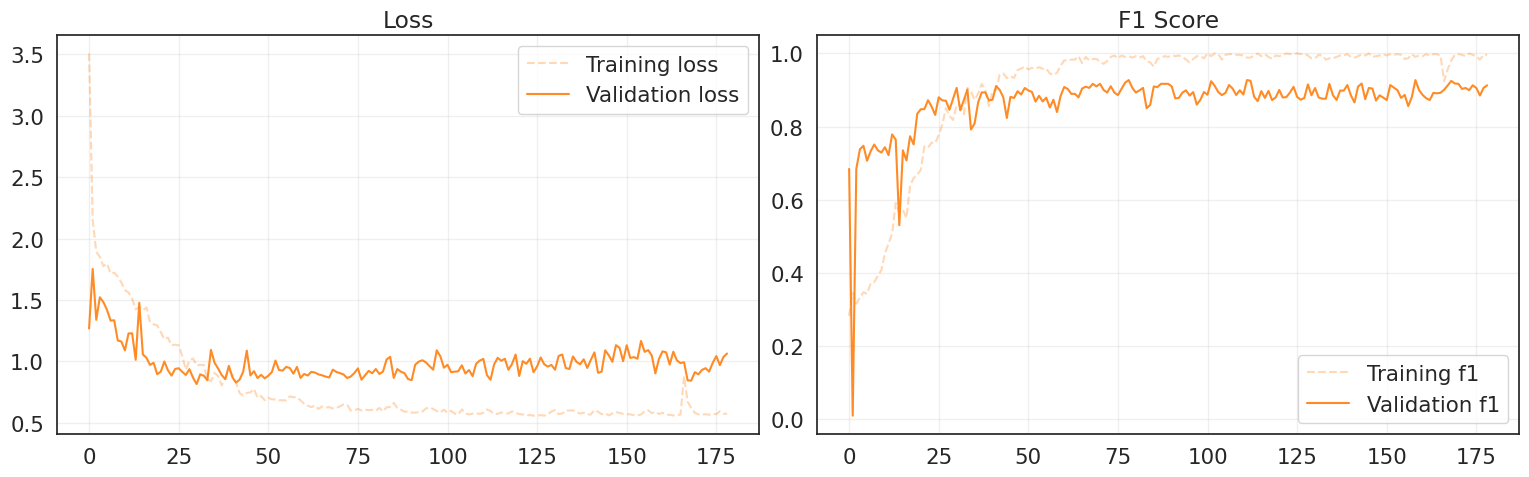

In [36]:
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9318
Precision over the validation set: 0.9331
Recall over the validation set: 0.9318
F1 score over the validation set: 0.9272


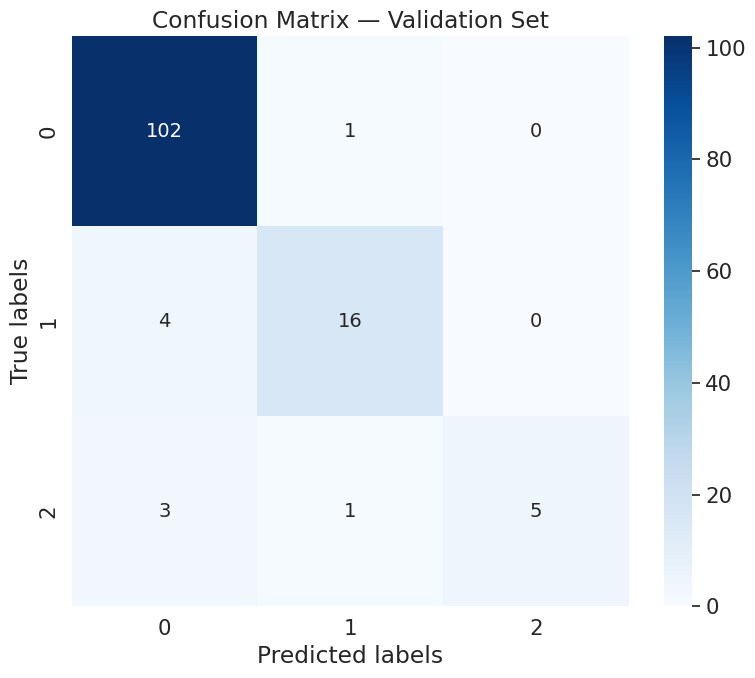

In [37]:
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, x_staticb, yb in val_loader:
        # Move data to device and convert to float32
        xb = xb.to(device).float()
        x_staticb = x_staticb.to(device).float()

        # Forward pass: get model predictions
        logits = model(xb, x_staticb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## Testing


In [ ]:
study.best_trial.params


{'lr': 0.000545755843370016,
 'batch_size': 16,
 'kernel_size': 3,
 'dropout': 0.1307106805799977,
 'gru_hidden': 256,
 'gru_layers': 3,
 'static_emb_dim': 16,
 'weight_decay': 0.00023118847573911345,
 'l1_lambda': 8.711968123800492e-05,
 'l2_lambda': 7.527730055211902e-07,
 'loss_variant': 'plain',
 'scheduler': 'cosine',
 'num_channels_1': 64,
 'num_channels_2': 64,
 'num_channels_3': 128}

In [28]:
best_params = {'lr': 0.000545755843370016,
 'batch_size': 16,
 'kernel_size': 3,
 'dropout': 0.1307106805799977,
 'gru_hidden': 256,
 'gru_layers': 3,
 'static_emb_dim': 16,
 'weight_decay': 0.00023118847573911345,
 'l1_lambda': 8.711968123800492e-05,
 'l2_lambda': 7.527730055211902e-07,
 'loss_variant': 'plain',
 'scheduler': 'cosine',
 'num_channels_1': 64,
 'num_channels_2': 64,
 'num_channels_3': 128}

In [30]:
seq_input_dim = X_train_seq.shape[2]
static_input_dim = X_train_static.shape[1]
num_classes = len(np.unique(y_train_seq))

tot_ch = 3
num_channels = [best_params[f"num_channels_{i+1}"] for i in range(tot_ch)]

In [38]:
model = TCNHybrid(
            seq_input_dim=seq_input_dim,
            static_input_dim=static_input_dim,
            num_classes=num_classes,
            num_channels=num_channels,
            kernel_size=best_params['kernel_size'],
            dropout=best_params['dropout'],
            gru_hidden=best_params['gru_hidden'],
            gru_layers=best_params['gru_layers'],
            static_emb_dim=best_params['static_emb_dim'],
            attn=True
        ).to(device)

model_path = BASE_PATH+"models/"+"tcn_optuna_model.pt"

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

TCNHybrid(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(34, 64, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
      (chomp1): Chomp1d()
      (norm1): InstanceNorm1d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (relu1): ReLU()
      (drop1): Dropout(p=0.1307106805799977, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
      (chomp2): Chomp1d()
      (norm2): InstanceNorm1d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (relu2): ReLU()
      (drop2): Dropout(p=0.1307106805799977, inplace=False)
      (downsample): Conv1d(34, 64, kernel_size=(1,), stride=(1,), bias=False)
      (final_relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,), bias=False)
      (chomp1): Chomp1d()
      (norm1): InstanceNorm1d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stat

In [39]:
# Check loaded model performance
val_loss, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation F1:   {val_f1:.4f}")

Validation Loss: 0.9225
Validation F1:   0.9272


In [40]:
num_joints = 29
scale_columns = [f'joint_{i:02d}' for i in range(num_joints+1)]

mins = X_test[scale_columns].min()
maxs = X_test[scale_columns].max()

for column in scale_columns:
    X_test[column] = (X_test[column] - mins[column]) / (maxs[column] - mins[column])

In [41]:
X_test_seq, X_test_static = build_sequences(X_test, WINDOW_SIZE, WINDOW_SIZE, is_test=True)

test_ds = TensorDataset(
    torch.from_numpy(X_test_seq),
    torch.from_numpy(X_test_static))

X_test_seq.shape, X_test_static.shape

1324


((1324, 200, 34), (1324, 3))

In [42]:
test_loader  = make_loader(test_ds, batch_size=best_params['batch_size'], shuffle=False, drop_last=False)

In [43]:
preds = []
with torch.no_grad():
    for (xb, x_staticb) in test_loader:
        xb = xb.to(device).float()
        x_staticb = x_staticb.to(device).float()
        logits = model(xb, x_staticb)
        batch_preds  = torch.argmax(logits, 1)
        preds.extend(batch_preds.cpu().numpy())

preds = np.array(preds)
print("Tot preds:", len(preds))
unique, counts = np.unique(preds, return_counts=True)
print("Distribution:", dict(zip(unique, counts)))

Tot preds: 1324
Distribution: {np.int64(0): np.int64(1077), np.int64(1): np.int64(171), np.int64(2): np.int64(76)}


In [44]:
label_map   = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [label_map[int(p)] for p in preds]

In [45]:
import datetime as dt

sample_submission = pd.read_csv("../Dataset/sample_submission.csv")

submission = sample_submission.copy()
submission["label"] = pred_labels

ts = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
submission.to_csv("submission.csv", index=False)
submission.to_csv(f"submission_{ts}.csv", index=False)

display(submission.head())

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,no_pain
3,3,no_pain
4,4,no_pain
